In [2]:
import importlib
import numpy as np
import matplotlib.pyplot as plt
import _shared

_shared = importlib.reload(_shared)
build_transmission_model = _shared.build_transmission_model

# Use a coarse setup so the documentation notebook runs quickly.
context = build_transmission_model(
    include_cia=False,
    include_rayleigh=False,
    download=False,
    nlayers=40,
 )
tm = context['tm']

In [3]:
tm.build()

In [4]:
out = tm.model()

In [ ]:
from taurex.data.spectrum import OffsetSpectraCont
obs = OffsetSpectraCont(path_spectra=['../../tmp/spectra/wasp39b_NRS1_Carter2024.txt', 
                                           '../../tmp/spectra/wasp39b_NRS2_Carter2024.txt'],
                            broadening_profiles = ['../../tmp/InstrumentFiles/jwst_nirspec_g395h_disp.fits', 
                                                   '../../tmp/InstrumentFiles/jwst_nirspec_g395h_disp.fits'],
                            max_wlbroadening=0.003, wlres=15000,
                            factor_cut=3)

FileNotFoundError: ../tmp/spectra/wasp39b_NRS1_Carter2024.txt not found.

In [86]:
inst_binner = obs.create_binner()
out_bin = inst_binner.bindown(out[0], out[1])

In [80]:
#spectrum._raw

<>:11: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
<>:11: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
/tmp/ipykernel_5653/348010052.py:11: SyntaxWarning: "\m" is an invalid escape sequence. Such sequences will not work in the future. Did you mean "\\m"? A raw string is also an option.
  plt.xlabel('Wavelength ($\mu$m)')


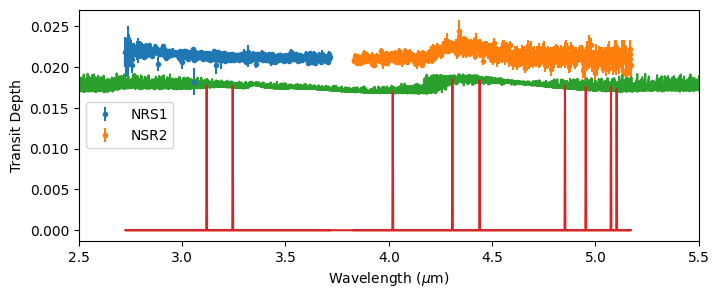

In [87]:
plt.figure(figsize=(8,3))
plt.errorbar(obs._raw[0][:,0],obs._raw[0][:,1], yerr=obs._raw[0][:,2], fmt='.', label='NRS1')
plt.errorbar(obs._raw[1][:,0],obs._raw[1][:,1], yerr=obs._raw[1][:,2], fmt='.', label='NSR2')
plt.plot(10000/out[0], out[1])

plt.plot(out_bin[0], out_bin[1])

plt.xlim(2.5, 5.5)

plt.legend()
plt.xlabel('Wavelength ($\mu$m)')
plt.ylabel('Transit Depth')
plt.show()

In [88]:
from taurex.optimizer import NestleOptimizer

In [89]:
from taurex.optimizer.nestle import NestleOptimizer

opt = NestleOptimizer(num_live_points=10, tol=30.0)
opt.set_model(tm)
opt.set_observed(obs)

opt.enable_fit('Offset_1')
opt.set_boundary('Offset_1', [-1e-2, 1e-2])

In [ ]:
opt.fit()